# 线性神经网络B
## Softmax回归
#### 分类问题
除了预测数值，机器学习还被期待用来对样本进行分类。分类即可以指我们对物品的硬性类别的区分（硬分类），也可以指我们某个物体有多少概率属于某个类别的预测（软分类），以上都属于分类问题。

假设我们获得了一个样本，样本本身是一个张量（如图片）。我们最后想把图片分类成具体的A B C…，那么我们就需要对ABC编号，比如给{A, B, C} 编号为{0, 1, 2}。这对于有自然顺序的分类（比如按年龄分类）很有益，因为这可以把分类问题尽可能地向回归问题靠近。

同时，还可以把分类化做一个向量，每个分类在向量中管理一个维度，比如我们确定向量三个维度分别是ABC,一个物品是A，则它的分类向量就是{1, 0, 0}。这种向量叫做独热编码。

独热编码的好处在于它很方便带入分类问题常用的损失函数：交叉熵 的公式里，同时，它也可以更好地表示软分类的情况（比如我可以把标签表示为概率向量 {0.1, 0.2, 0.7}）。

关于损失函数部分在后文涉及。

#### 网络架构

假设我们面对的是一个把四个特征的物品按照三种类别去分类，则可以针对每个类别建立一个根据四个特征确立的仿射函数。如：

$o_1 = x_1 w_{11} + x_2 w_{12} + x_3 w_{13} + x_4 w_{14} + b_1$

$o_2 = x_1 w_{21} + x_2 w_{22} + x_3 w_{23} + x_4 w_{24} + b_2$

$o_3 = x_1 w_{31} + x_2 w_{32} + x_3 w_{33} + x_4 w_{34} + b_3$

值得注意的是，这里的o是未规范化的预测，而非我们所期待的概率。我们最终还需借助softmax把它们变成我们所需的具体概率。此为后言。

这是Softmax回归中第一部分，作为Softmax函数的输入。

这里依旧可以用向量化方式表示以上的仿射函数，即$\mathbf{o} = \mathbf{Wx} + \mathbf{b}$. 显然这里每个字母都是向量或矩阵。依据此式，计算的时候可以让其高度矢量化，以加快训练时间。

可见每个输出利用了全部的输入，显然这也是一个全连接层。全连接层的消耗是惊人的，复杂度能达到$\mathbf{O} (dq)$. 而事实上，参数开销可以借助卷积等方式降到$\mathbf{O} (\frac{dq}{n})$，其中$n$为可调超参数，此处暂且不表。

#### Softmax运算
Softmax函数如下所示

$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o})\quad \text{其中}\quad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$

它把未规范化的预测（logit）$\mathbf{o}$ 转化为一个合法的概率分布（非负且和为 1）。训练迭代改进的是这些概率对真实分布的近似程度。

考虑到$\exp{x}$是一个单调递增的函数，可以得知Softmax函数不会影响原输入之间的大小关系。因此，当模型训练完毕后，我们调取模型预测时，直接取概率最大的那个量作为预测结果即可。

比如预测结果为{P(A), P(B), P(C)} = {0.1, 0.2, 0.7}，我们可以认为这个样本就是C类。

#### 损失函数
首先，我们需要计算目前模型的似然估计，即把每个样本的似然相乘

$P(\mathbf{Y} \mid \mathbf{X}) = \prod_{i=1}^n P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}).$

若使P最大，我们可以取负对数，使之最小，即趋近0。此时上式化为

$-\log P(\mathbf{Y} \mid \mathbf{X}) = \sum_{i=1}^n -\log P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)})
= \sum_{i=1}^n l(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)})$

对于单个样本的损失函数 $l(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)})$，它是对每个类别的预测概率取对数后按标签加权求和（再取负），即

$ l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j. $

此为**交叉熵函数**，对于硬分类，我们期待最终的结果趋近0，而对于软分类，其最终结果会趋近于样本原本的熵$H(P)$，而非0.但是我们期待其向0靠近的目标是不变的。

#### 求导
带入softmax公式、拆分对数内的分式可以得到：

$\text{原式}=\log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j.$

对第j项o求导直接化为$\mathrm{softmax}(\mathbf{o})_j - y_j.$

#### 信息论基础
对于交叉熵，前文提到，当Q与P相同时，模型就优化到极致了，此时残存的数值就是原分布的熵，即

$H(P,Q) = -\sum_j P(j)\log Q(j)$，当$Q=P$时，$H(P,Q)=H(P)=-\sum_j P(j)\log P(j)$

根据信息论，我们至少需要$H(P)$个“纳特”进行编码，$1$ nat=$\frac{1}{\log{2}}$ bit

## 图像分类数据集
使用的数据集为Fashion-MNIST.
## 读取数据集
可以使用torchvision下载+读取数据集

In [ ]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

trans = transforms.ToTensor()       # 设置转换器：把图片转换为张量
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

print(f'len_train {len(mnist_train)}, len_test {len(mnist_test)}')
print(f'shape {mnist_test[0][0].shape}')
# 三维张量，分别代表通道（灰度图像只有一个）、长、宽


len_train 60000, len_test 10000
shape torch.Size([1, 28, 28])


Fashion-MNIST包含十个类别，具体参考下面代码

In [3]:
def get_fm_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

    return [text_labels[int(i)] for i in labels]    # 兼容各种输入

下面代码块可以可视化部分样本

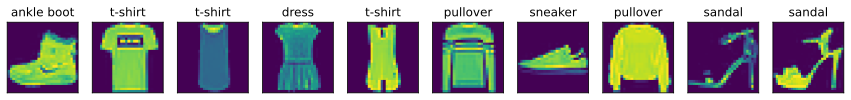

In [11]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])

X, y = next(iter(data.DataLoader(mnist_train, batch_size=10)))
show_images(X.reshape(10, 28, 28), 1, 10, titles=get_fm_labels(y))

#### 小批量样本读取
使用内部迭代器可以从总体样本中随机抽取一部分样本

In [ ]:
batch_size = 256

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0)
# 最后一个参数是用来规定读取数据的线程数的

timer = d2l.Timer()
for X, y in train_iter: # 每次从迭代器随机取batch_size个样本给X、y，
                        # 且多次循环遍历完样本集，不重不漏
    continue
print(f'{timer.stop():.2f} s.')

2.32 s.


## Softmax 回归从零实现
#### 初始化模型参数
 